## LinkedIn Jobs Market EDA

### 1. Importing Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


### 2. Loading Dataset

In [11]:
df = pd.read_csv(r"C:\Users\baisa\OneDrive\Documents\DataScience_AI\Datasets\postings.csv")
print("Dataset loaded!")

Dataset loaded!


### 3.  Dataset Overview

In [12]:
df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [9]:
print(f"Shape : {df.shape}")
print("\nColumns Names :\n")
print(df.columns.tolist())
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows:{df.duplicated().sum()}")

Shape : (123849, 31)

Columns Names :

['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']

Data Types:
job_id                          int64
company_name                   object
title                          object
description                    object
max_salary                    float64
pay_period                     object
location                       object
company_id                    float64
views                         float64
med_salary                    float64
min_salary                    float64
formatted_work_type            object
applies      

### 4. Data Cleaning

In [13]:
# droping the columns not useful for analysis
cols_to_drop = ['job_id','company_id','job_posting_url','application_url',
                'posting_domain','zip_code','fips','closed_time',
                'expiry','application_type']
df.drop(columns=cols_to_drop, inplace=True)
print(f"Remaining columns: {df.shape[1]}")
print(f"\n{df.columns.tolist()}")

Remaining columns: 21

['company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'formatted_experience_level', 'skills_desc', 'listed_time', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary']


In [16]:
# Fill missing remote_allowed with 0 (not remote)
df['remote_allowed'] = df['remote_allowed'].fillna(0)

# Drop rows where title or company_name is missing (very few, not useful)
df.dropna(subset=['title', 'company_name'], inplace=True)

print("Basic cleaning done!")
print(f"Final shape: {df.shape}")

Basic cleaning done!
Final shape: (122130, 21)


### 5. Top Job Titles Analysis

- Analyzing the most frequently posted job titles to identify which roles are most in demand on LinkedIn.

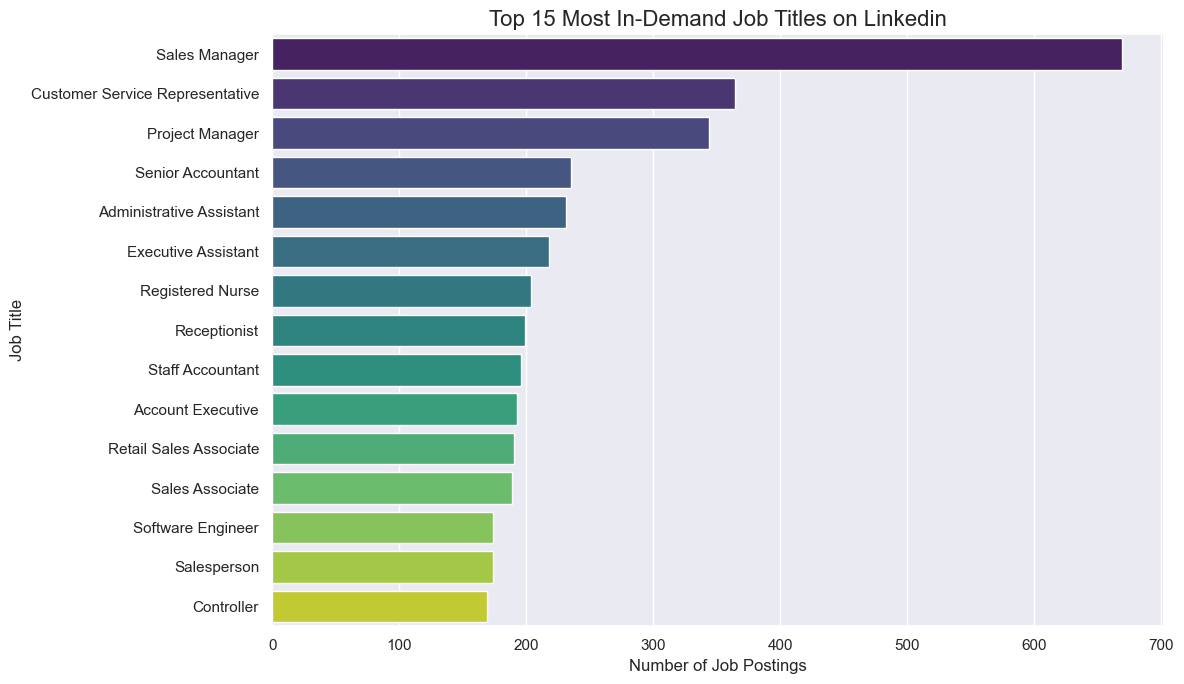

In [27]:
top_titles = df['title'].value_counts().head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_titles.values, y=top_titles.index, palette='viridis')
plt.title("Top 15 Most In-Demand Job Titles on Linkedin", fontsize=16)
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")
plt.tight_layout()
plt.savefig("top_job_titles.png", dpi=150)
plt.show()

### 6. Top Hiring Companies

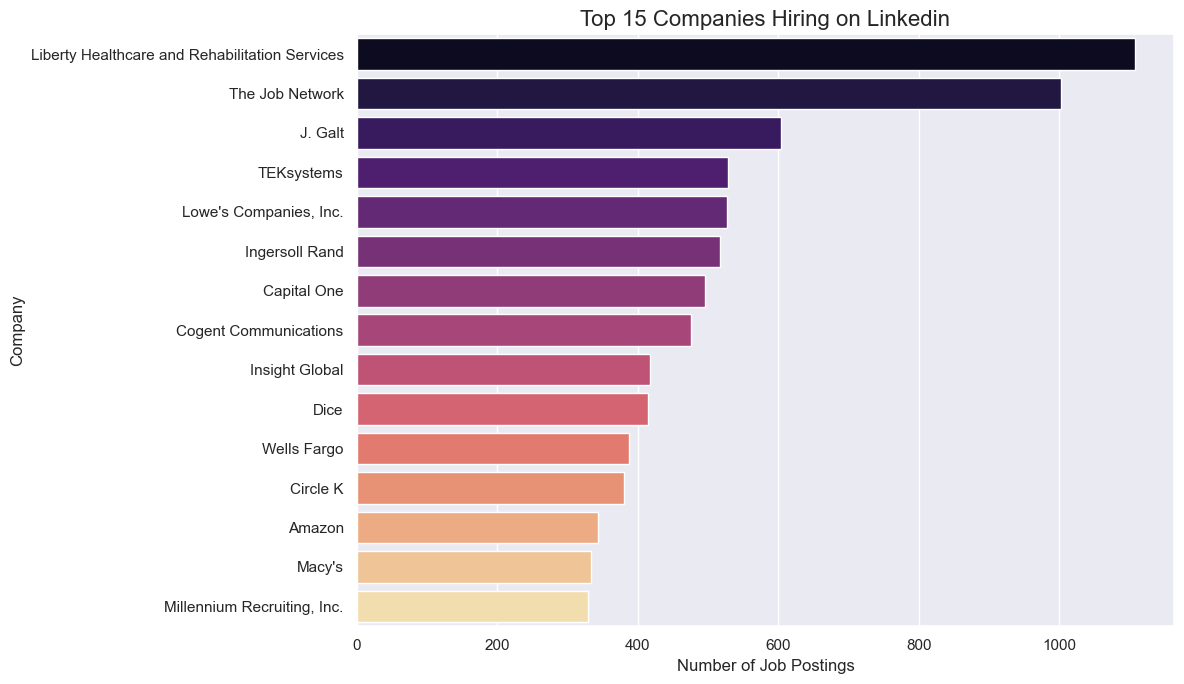

In [28]:
top_companies = df['company_name'].value_counts().head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_companies.values, y=top_companies.index, palette='magma')
plt.title("Top 15 Companies Hiring on Linkedin", fontsize=16)
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")
plt.tight_layout()
plt.savefig("top_companies.png", dpi=150)
plt.show()

### 7. Top Hiring Locations

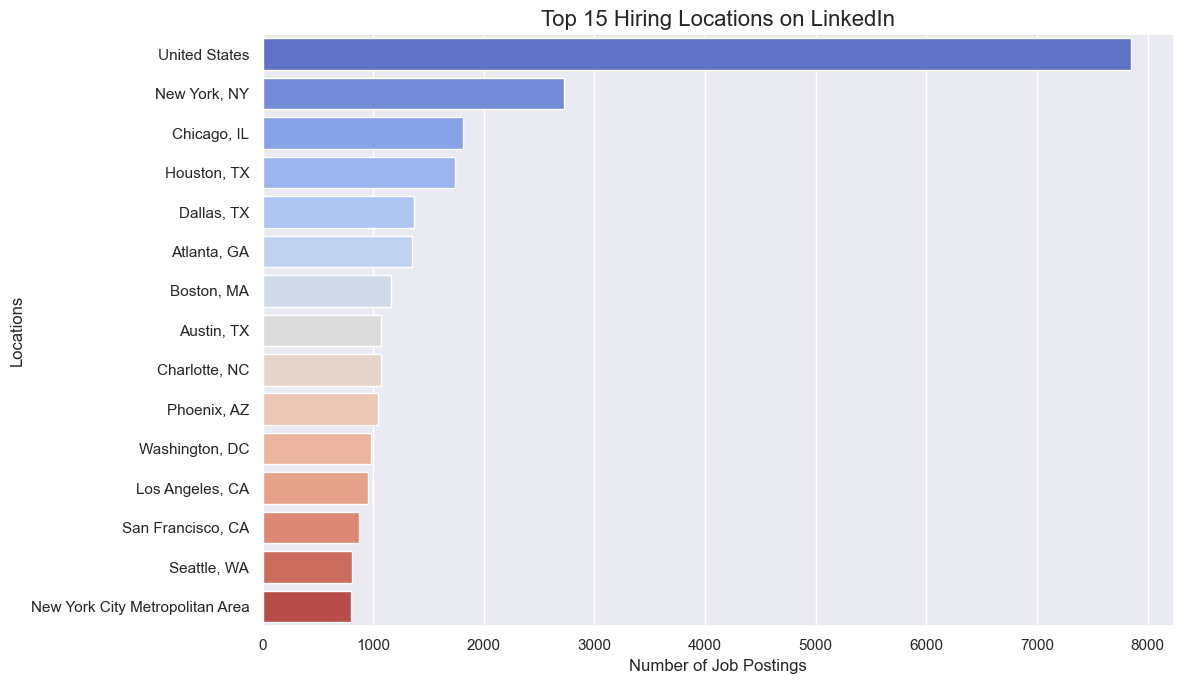

In [31]:
top_locations = df['location'].value_counts().head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='coolwarm')
plt.title("Top 15 Hiring Locations on LinkedIn", fontsize=16)
plt.xlabel("Number of Job Postings")
plt.ylabel("Locations")
plt.tight_layout()
plt.savefig("top_locations.png", dpi=150)
plt.show()


### 8. Experience level Distribution

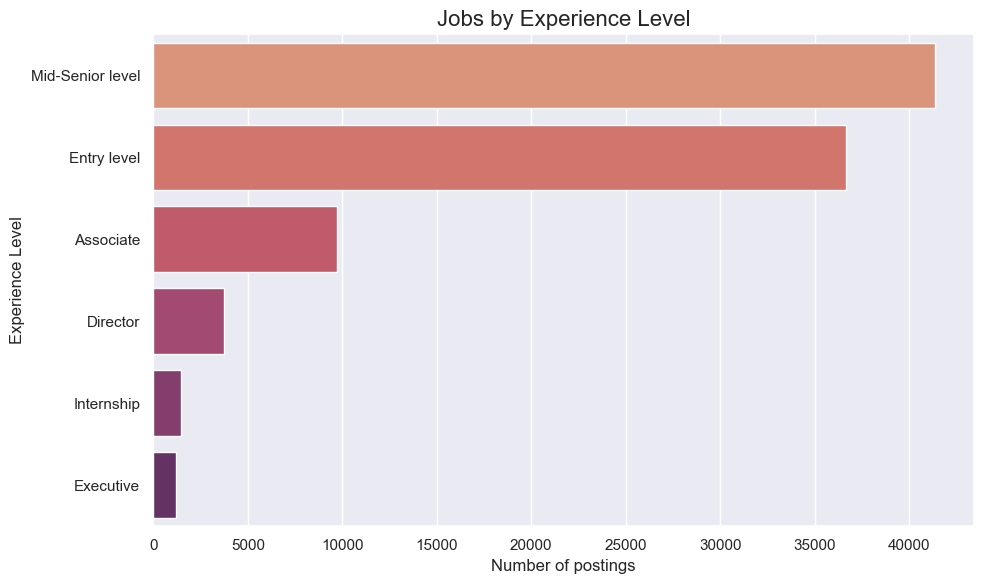


Experience Level Breakdown (%):
formatted_experience_level
Mid-Senior level    43.92
Entry level         38.95
Associate           10.34
Director             3.96
Internship           1.54
Executive            1.29
Name: count, dtype: float64


In [37]:
exp_counts = df['formatted_experience_level'].value_counts().dropna()

plt.figure(figsize=(10, 6))
sns.barplot(x=exp_counts.values, y=exp_counts.index, palette="flare")
plt.title("Jobs by Experience Level", fontsize=16)
plt.xlabel("Number of postings")
plt.ylabel("Experience Level")
plt.tight_layout()
plt.savefig("experience_level.png", dpi=150)
plt.show()

print("\nExperience Level Breakdown (%):")
print(round(exp_counts / exp_counts.sum() * 100, 2))

### 9. Work Type Distribution

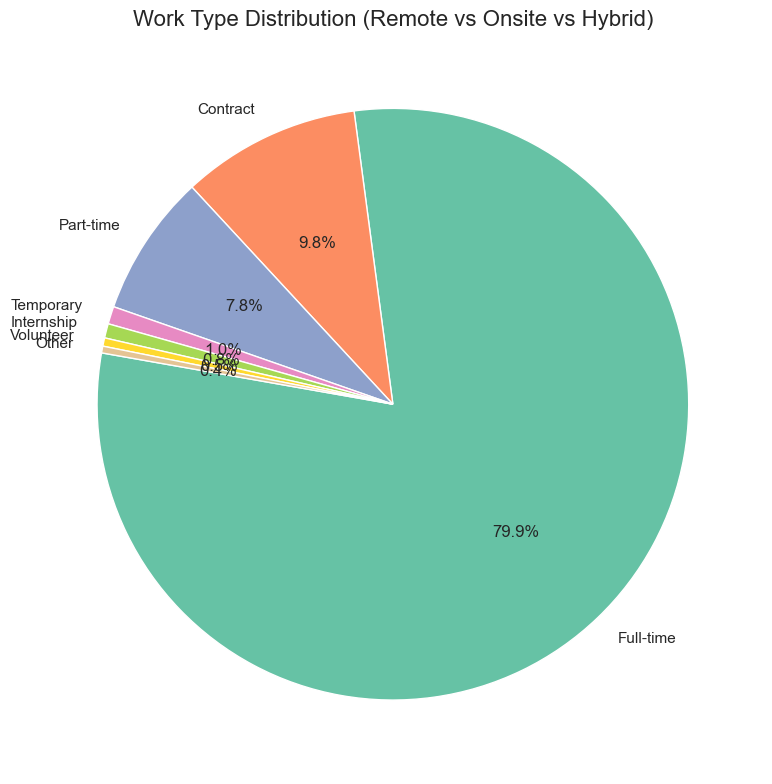


Work Type Breakdown :
formatted_work_type
Full-time     97552
Contract      11955
Part-time      9488
Temporary      1176
Internship      955
Volunteer       555
Other           449
Name: count, dtype: int64


In [53]:
work_counts = df['formatted_work_type'].value_counts().dropna()

plt.figure(figsize=(10, 8))
plt.pie(work_counts.values,
        labels=work_counts.index,
        autopct="%1.1f%%",
       colors=sns.color_palette('Set2'),
        startangle=170)

plt.title("Work Type Distribution (Remote vs Onsite vs Hybrid)", fontsize=16)
plt.tight_layout()
plt.savefig("work_type.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nWork Type Breakdown :")
print(work_counts)

#### Insights : 
- 79.9% of LinkedIn jobs are Full-time positions, with Contract roles at 9.8%

### 10. Remote vs Onsite Analysis

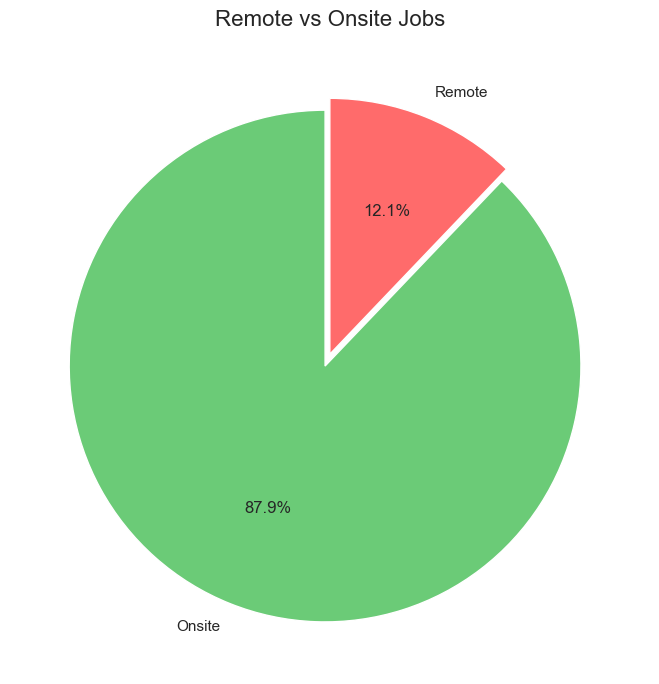


Work Location Breakdown:
work_location
Onsite    107316
Remote     14814
Name: count, dtype: int64


In [56]:
# Creating work location category from remote_allowed
df['work_location'] = df['remote_allowed'].apply(
    lambda x: 'Remote' if x == 1.0 else 'Onsite'
)

work_location_counts = df['work_location'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(work_location_counts.values,
       labels=work_location_counts.index,
        autopct="%1.1f%%",
        colors=['#6bcb77', '#ff6b6b'],
        startangle=90,
        explode=(0.05, 0))

plt.title("Remote vs Onsite Jobs", fontsize=16)
plt.tight_layout()
plt.savefig("remote_vs_onsite.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nWork Location Breakdown:")
print(work_location_counts)

### Insight :

- Only 12.1% of LinkedIn jobs allow remote work --> meaning most jobs still require physical presence.

**Note :**

- The dataset does not contain explicit Hybrid work type information.
- Jobs are classified as Remote or Onsite based on the 'remote_allowed' column.

### 11. Remote Allowed Analysis

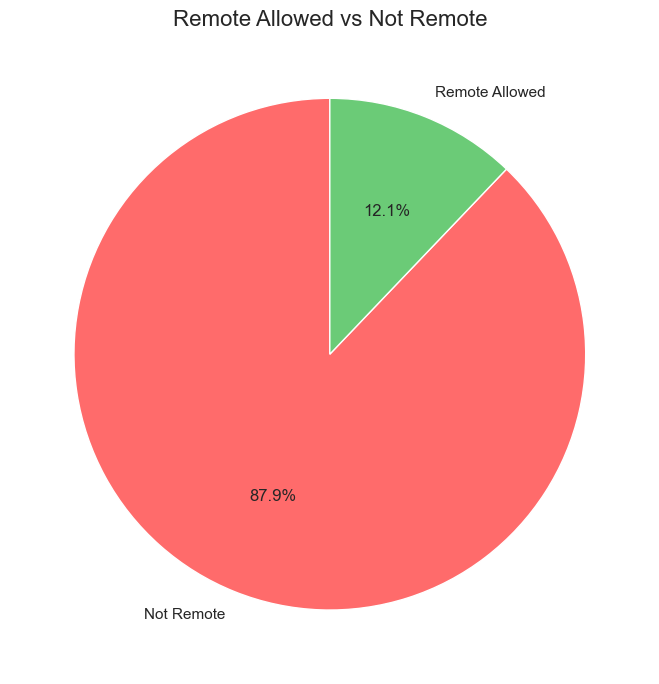

In [52]:
remote_counts = df['remote_allowed'].value_counts()
remote_counts.index = ['Not Remote', 'Remote Allowed']

plt.figure(figsize=(7, 7))
plt.pie(remote_counts.values, labels=remote_counts.index, autopct='%1.1f%%',
       colors=['#ff6b6b', '#6bcb77'], startangle=90)
plt.title("Remote Allowed vs Not Remote", fontsize=16)
plt.tight_layout()
plt.savefig("remote_allowed.png", dpi=150)
plt.show()

### 12. Salary Analysis

In [57]:
print("Salary columns info :")
print(df[['min_salary', 'max_salary', 'med_salary', 'normalized_salary']].describe())

print(f"\nMissing values:")
print(df[['min_salary', 'max_salary', 'med_salary', 'normalized_salary']].isnull().sum())

Salary columns info :
         min_salary    max_salary     med_salary  normalized_salary
count  2.933800e+04  2.933800e+04    6225.000000       3.556300e+04
mean   6.511109e+04  9.224880e+04   22007.328069       2.070071e+05
std    4.997555e+05  7.064466e+05   52387.406391       5.134025e+06
min    1.000000e+00  1.000000e+00       0.000000       0.000000e+00
25%    3.750000e+01  4.867500e+01      18.860000       5.200000e+04
50%    6.020000e+04  8.000000e+04      25.370000       8.185000e+04
75%    1.000000e+05  1.400000e+05    2500.000000       1.250000e+05
max    8.500000e+07  1.200000e+08  750000.000000       5.356000e+08

Missing values:
min_salary            92792
max_salary            92792
med_salary           115905
normalized_salary     86567
dtype: int64


### Clean & Plot Salary

In [59]:
#  Filtering valid salary data and remove outliers
salary_df = df[['normalized_salary', 'formatted_experience_level']].dropna()

# Removing extreme outliers (keep between 10k and 500k - realistic salary range)
salary_df = salary_df[
        (salary_df['normalized_salary'] >= 10000) &
        (salary_df['normalized_salary'] <= 50000)
]

print(f"Valid salary records: {len(salary_df)}")
print(salary_df['normalized_salary'].describe())

Valid salary records: 6293
count     6293.000000
mean     39718.286170
std       6757.723338
min      10000.000000
25%      35360.000000
50%      40040.000000
75%      45000.000000
max      50000.000000
Name: normalized_salary, dtype: float64


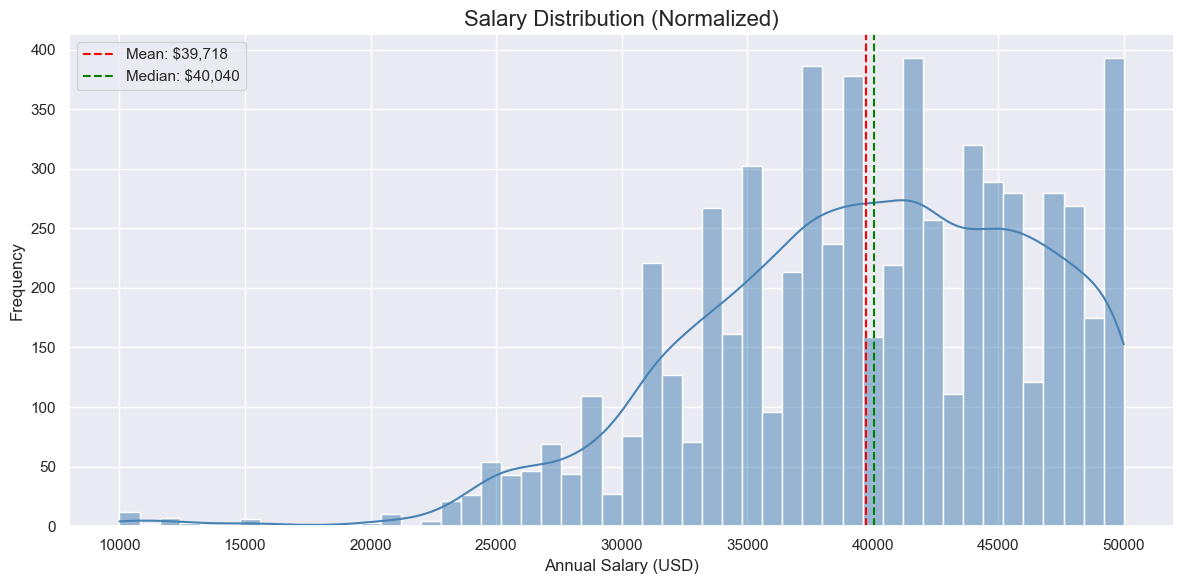

In [61]:
plt.figure(figsize=(12, 6))
sns.histplot(salary_df['normalized_salary'], bins=50, kde=True, color='steelblue')
plt.title("Salary Distribution (Normalized)", fontsize=16)
plt.xlabel("Annual Salary (USD)")
plt.ylabel("Frequency")
plt.axvline(salary_df['normalized_salary'].mean(), color='red',
           linestyle='--', label=f"Mean: ${salary_df['normalized_salary'].mean():,.0f}")
plt.axvline(salary_df['normalized_salary'].median(), color='green',
           linestyle='--', label=f"Median: ${salary_df['normalized_salary'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.savefig("salary_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


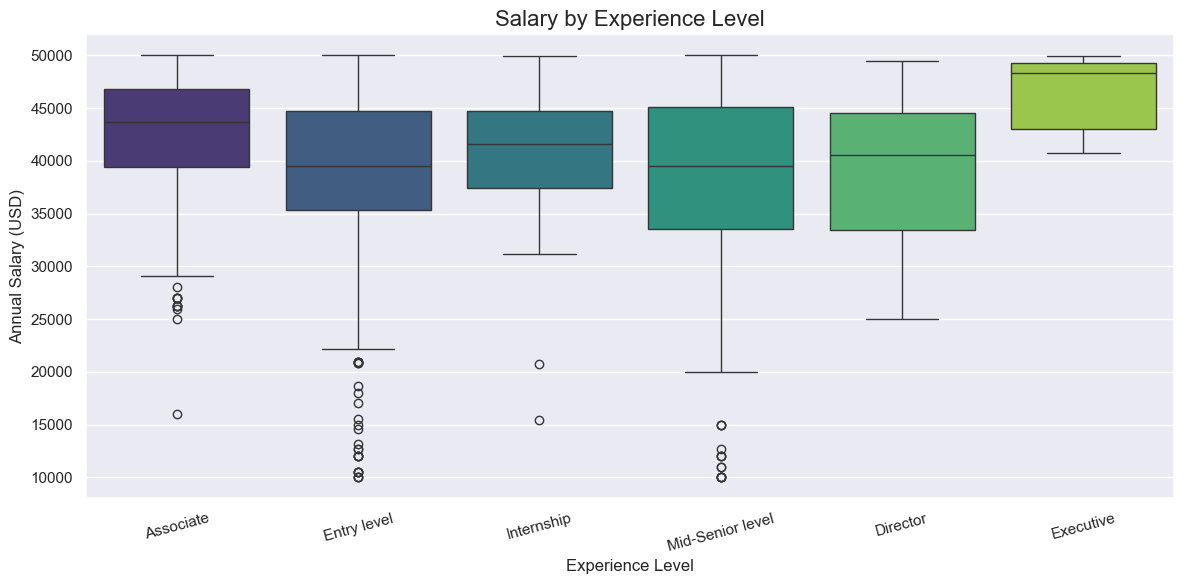

In [63]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=salary_df, x='formatted_experience_level',
           y='normalized_salary', palette='viridis')
plt.title("Salary by Experience Level", fontsize=16)
plt.xlabel("Experience Level")
plt.ylabel("Annual Salary (USD)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("salry_by_experience.png", dpi=150, bbox_inches='tight')
plt.show()

### Insights :

- Average salary on LinkedIn job postings is around $40K annually. 
- Executive level roles command the highest salaries, as expected. 
- Only 5% of job postings include salary information --> **a major limitation of this dataset.**

### 13. Most In-Demand Skills Analysis

In [73]:
# Extracting skills from skills_desc column
skills_text = " ".join(df['skills_desc'].dropna()).lower()

# Comon words to ignore
stopwords = set([
    'and', 'the', 'to', 'of', 'in', 'a', 'with', 'for', 'is', 'are', 
    'you', 'we', 'our', 'your', 'or', 'an', 'be', 'as', 'at', 'on',
    'this', 'that', 'it', 'by', 'from', 'will', 'have', 'has', 'not',
    'but', 'they', 'their', 'its', 'all', 'can', 'more', 'other',
    'about', 'up', 'than', 'also', 'into', 'new', 'some', 'work',
    'experience', 'ability', 'skills', 'working', 'including', 'team',
    'strong', 'required', 'related', 'across', 'within', 'must',
     'position', 'following', 'requires', 'years', 'knowledge',
    'job', 'care', 'following', 'role', 'looking', 'seeking',
    'responsibilities', 'qualifications', 'preferred', 'plus',
    'equivalent', 'degree', 'field', 'relevant', 'minimum',
    'candidates', 'candidate', 'apply', 'equal', 'opportunity',
    'employer', 'employment', 'salary', 'benefits', 'offer',
    'join', 'help', 'ensure', 'provide', 'support', 'develop',
    'manage', 'use', 'used', 'using', 'proven', 'track', 'record',
    'high', 'level', 'well', 'good', 'excellent', 'effective',
    'both', 'between', 'through', 'while', 'who', 'what', 'when',
    'been', 'such', 'may', 'any', 'one', 'two', 'three', 'least'
])

# Extracting words
words = re.findall(r'\b[a-z]{3,}\b', skills_text)
filtered_words = [w for w in words if w not in stopwords]

top_skills = Counter(filtered_words).most_common(20)
skills_df = pd.DataFrame(top_skills, columns=['skills', 'count'])

print(skills_df)

           skills  count
0      management    285
1   communication    199
2        customer    196
3    requirements    170
4         service    170
5        business    167
6          office    147
7        employee    146
8        physical    145
9       education    139
10         people    139
11           time    139
12        perform    136
13    development    129
14    environment    127
15        written    123
16           able    119
17           data    116
18     healthcare    111
19          sales    108


In [78]:
python_counts = skills_text.count('python')
sql_counts = skills_text.count('sql')
excel_counts = skills_text.count('excel')

print(f"Python mentions : {python_counts}")
print(f"SQL mentions    : {sql_counts}")
print(f"Excel mentions  : {excel_counts}")

Python mentions : 28
SQL mentions    : 51
Excel mentions  : 200


In [79]:
# Define specific skills to search for
specific_skills = [
    'python', 'sql', 'excel', 'java', 'javascript', 'communication',
    'management', 'leadership', 'customer service', 'sales', 'marketing',
    'healthcare', 'data analysis', 'project management', 'teamwork',
    'microsoft office', 'powerpoint', 'word', 'tableau', 'power bi',
    'machine learning', 'aws', 'azure', 'accounting', 'finance',
    'human resources', 'recruiting', 'training', 'budgeting', 'research'
]

# Counting each skill
skill_counts = {}
for skill in specific_skills:
    skill_counts[skill] = skills_text.count(skill)

# Converting to dataframe and sorting
specific_skills_df = pd.DataFrame(
    skill_counts.items(), columns=['skill', 'count']
).sort_values('count', ascending=False)

print(specific_skills_df.head(15))

               skill  count
6         management    297
5      communication    243
9              sales    215
2              excel    200
11        healthcare    113
8   customer service     92
10         marketing     78
23        accounting     78
27          training     67
15  microsoft office     53
29          research     53
1                sql     51
7         leadership     47
17              word     47
3               java     46


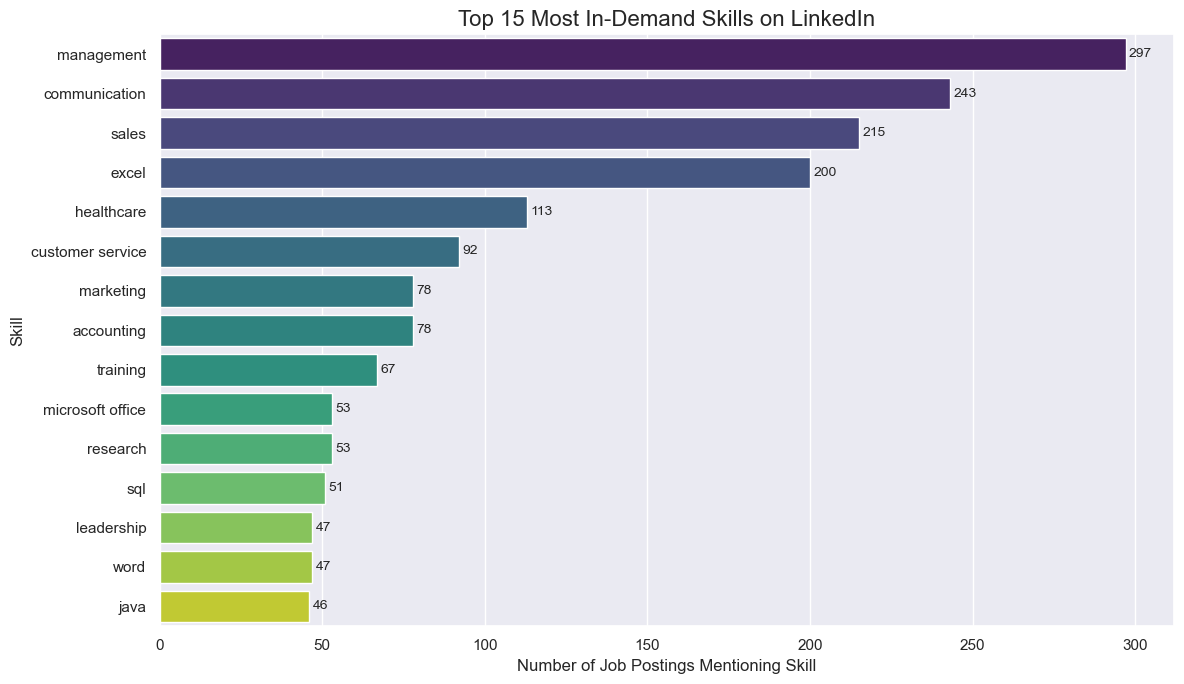

In [81]:
plt.figure(figsize=(12, 7))
sns.barplot(data=specific_skills_df.head(15),
           x='count', y='skill', palette='viridis')
plt.title("Top 15 Most In-Demand Skills on LinkedIn", fontsize=16)
plt.xlabel("Number of Job Postings Mentioning Skill")
plt.ylabel("Skill")

# Adding value labels on bars
for i, v in enumerate(specific_skills_df.head(15)['count']):
    plt.text(v + 1, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig("top_skills.png", dpi=150, bbox_inches='tight')
plt.show()    

### Insights :

- Management, Communication and Sales are the top 3 ,ost in-demand skills.
- Excel is the most sought-after technical tool, appearing in 200 job postings.
- SQL and Python have relatively low counts because this dataset is 
   **dominated by Non-tech roles** like Sales, Healthcare and Customer Service.
- For as aspiring Data Scientists, SQL and Excel remain essential baseline skills.


### 14. Job Views & Application Analysis

In [86]:
engage_df = df[['title', 'views', 'applies']].dropna()

print(f"Valid engagement records : {len(engage_df)}")
print(engage_df[['views', 'applies']].describe())

Valid engagement records : 22894
              views       applies
count  22894.000000  22894.000000
mean      55.788416     10.535817
std      191.085493     28.848771
min        1.000000      1.000000
25%       12.000000      1.000000
50%       23.000000      3.000000
75%       49.000000      8.000000
max     9975.000000    967.000000


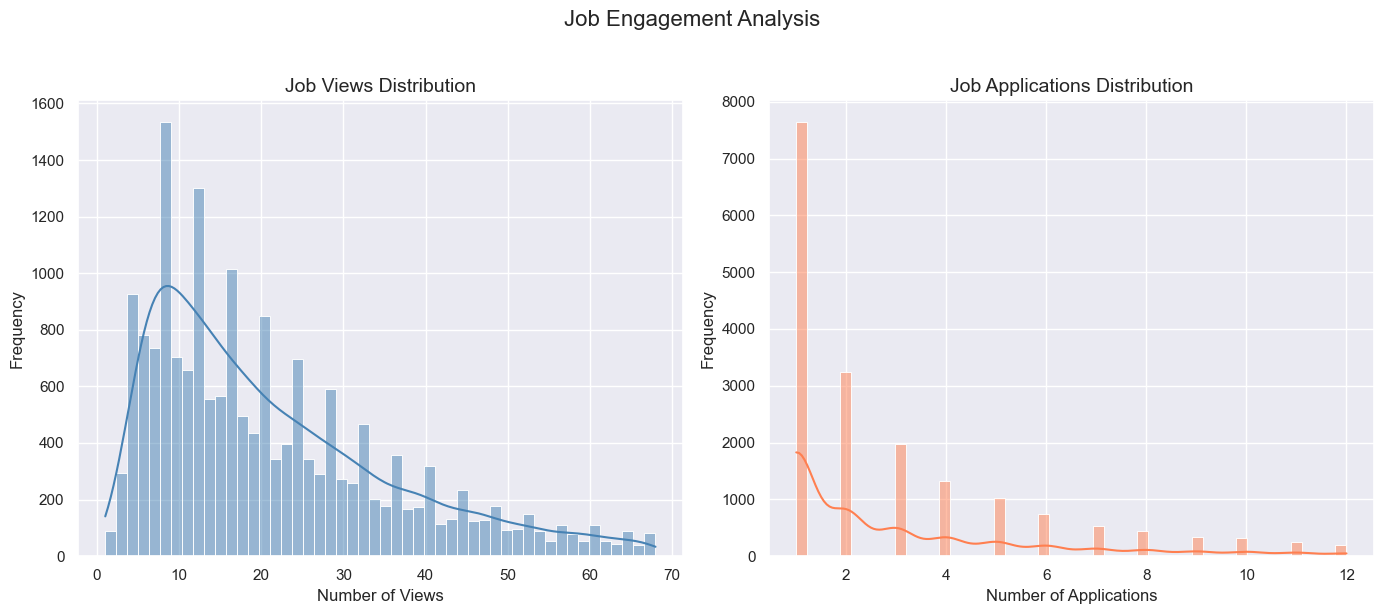

In [90]:
# removing outliers for cleaner visualization
engage_df = engage_df[
        (engage_df['views'] < engage_df['views'].quantile(0.95)) &
        (engage_df['applies'] < engage_df['applies'].quantile(0.95))
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Views distribution
sns.histplot(engage_df['views'], bins=50, kde=True,
            color='steelblue', ax=axes[0])
axes[0].set_title("Job Views Distribution", fontsize=14)
axes[0].set_xlabel("Number of Views")
axes[0].set_ylabel("Frequency")

# Applies distribution
sns.histplot(engage_df['applies'], bins=50, kde=True,
            color='coral', ax=axes[1])
axes[1].set_title("Job Applications Distribution", fontsize=14)
axes[1].set_xlabel("Number of Applications")
axes[1].set_ylabel("Frequency")

plt.suptitle("Job Engagement Analysis", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("job_engagement.png", dpi=150, bbox_inches='tight')
plt.show()

In [92]:
# Apply rate = applies / views
engage_df['apply_rate'] = engage_df['applies'] / engage_df['views'] * 100

print(f"Average Apply Rate: {engage_df['apply_rate'].mean():.2f}%")

print("\nTop 10 Most Viewd Jobs:")
print(engage_df.nlargest(10, 'views')[['title', 'views', 'applies']].to_string())

Average Apply Rate: 15.56%

Top 10 Most Viewd Jobs:
                                                title  views  applies
1219                              Operations Research   68.0      7.0
5194                           Senior Program Manager   68.0      8.0
8454                Python React Full Stack Developer   68.0     12.0
10266       Project Manager - Change Manager - Expert   68.0     12.0
10418                            Salesforce Architect   68.0      7.0
11312  Kipling: Email Marketing Specialist (Americas)   68.0      9.0
15861                Vice President of Sales-Americas   68.0     11.0
17925                                      Co-Founder   68.0     12.0
36159            Associate Convention Project Manager   68.0      9.0
39036                              Facilities Manager   68.0      8.0


### Insights :
- Average job apply rate is 15.56% — meaning roughly 1 in 6 viewers apply.
- Most jobs receive between 5-20 views, showing majority are niche postings.
- Applications are heavily skewed — most jobs get only 1-2 applications.
- Top viewed jobs are mostly Senior and Specialized roles.

## 15. Key Insights & Conclusions

###  About the Dataset
- Dataset contains 122,130 LinkedIn job postings across the USA.
- Only 5% of postings include salary information — a major limitation.

###  Job Market Trends
- Sales Manager, Customer Service Representative and Project Manager 
  are the top 3 most in-demand roles.
- Mid-Senior level roles dominate the market, but Entry level is #2.
- 79.9% of jobs are Full-time positions.

###  Location & Remote Work
- Only 12.1% of jobs allow remote work — physical presence is still the norm.

###  Salary
- Average normalized salary is around $40K annually.
- Executive level roles command the highest salaries.

###  Skills
- Management, Communication and Sales are the top skills.
- Excel is the most in-demand technical tool.
- This dataset is dominated by non-tech roles — SQL and Python 
  have low counts compared to soft skills.

###  Job Engagement
- Average apply rate is 15.56% — 1 in 6 viewers apply.
- Most jobs receive between 5-20 views showing niche postings dominate.